<a href="https://colab.research.google.com/github/Siddharth703k/Waste-Segregation-Project/blob/main/min.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Import Libraries**

In [ ]:
import os
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential, load_model
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout

**Mount Google Drive**

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


**Path Defining**

In [ ]:
dataset_zip_path = '/content/drive/MyDrive/detl/archive.zip'
dataset_path = '/content/dataset-resized'
model_path = '/content/drive/MyDrive/waste_classifier.h5'

***Data Preprocessing***

In [ ]:
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    zoom_range=0.2,
    horizontal_flip=True,
    validation_split=0.2
)

**Load Training Data**

In [ ]:
train_generator = train_datagen.flow_from_directory(
    dataset_path,
    target_size=(224, 224),
    batch_size=32,
    class_mode='categorical',
    subset='training'
)

Found 2022 images belonging to 1 classes.


**Load Validation**

In [ ]:
val_generator = train_datagen.flow_from_directory(
    dataset_path,
    target_size=(224, 224),
    batch_size=32,
    class_mode='categorical',
    subset='validation'
)

Found 505 images belonging to 1 classes.


***CNN Model***

In [ ]:
model = Sequential([
    Conv2D(32, (3,3), activation='relu', input_shape=(224,224,3)),
    MaxPooling2D(2,2),

    Conv2D(64, (3,3), activation='relu'),
    MaxPooling2D(2,2),

    Conv2D(128, (3,3), activation='relu'),
    MaxPooling2D(2,2),

    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.5),

    Dense(6, activation='softmax')  # 6 classes
])

**Compile Model**

In [ ]:
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

**Train Model**

In [ ]:
if os.path.exists(model_path):
    model = load_model(model_path)
    print("Model loaded from Drive. Skipping training.")
else:
    history = model.fit(
        train_generator,
        validation_data=val_generator,
        epochs=10
    )
    model.save(model_path)
    print("Model trained and saved.")

Model loaded from Drive. Skipping training.


**Graph**

In [ ]:
if 'history' in locals():
    plt.plot(history.history['accuracy'])
    plt.plot(history.history['val_accuracy'])
    plt.title('Model Accuracy')
    plt.ylabel('Accuracy')
    plt.xlabel('Epoch')
    plt.legend(['Train', 'Validation'])
    plt.show()

**Upload Test Image**

In [ ]:
from google.colab import files
uploaded = files.upload()

img_path = list(uploaded.keys())[0]
print("Uploaded image:", img_path)

Saving paper.jpeg to paper.jpeg
Uploaded image: paper.jpeg


**Pre-Process Image**

In [ ]:
from tensorflow.keras.preprocessing import image

img = image.load_img(img_path, target_size=(224,224))
img_array = image.img_to_array(img) / 255.0
img_array = np.expand_dims(img_array, axis=0)

**Predict**

In [ ]:
pred = model.predict(img_array)

labels = ['cardboard','glass','metal','paper','plastic','trash']
predicted_class = labels[np.argmax(pred)]
confidence = np.max(pred)

print("Prediction:", predicted_class)
print("Confidence:", confidence)

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
Prediction: paper
Confidence: 0.6560905


**DISPLAY**

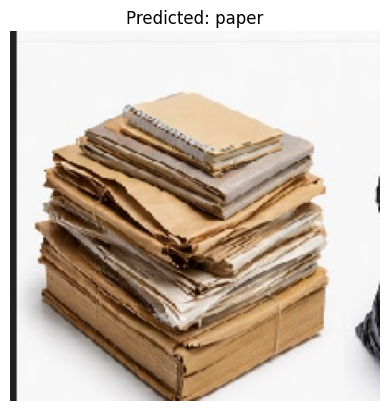

In [ ]:
plt.imshow(img)
plt.axis('off')
plt.title(f"Predicted: {predicted_class}")
plt.show()